# ❤️ Heart Disease Prediction using Machine Learning

**Internship Project — Edunet Foundation / IBM SkillsBuild**

### Problem Statement
Cardiovascular disease is one of the leading causes of death worldwide. Early prediction of
heart disease risk from routinely-collected clinical parameters can help doctors prioritize
patients and enable earlier intervention. This project builds and compares several supervised
machine learning classification models to predict the presence of heart disease in a patient
based on 13 clinical features.

### Dataset
UCI Machine Learning Repository — **Heart Disease (Cleveland) Dataset**, 303 patient records,
13 features + 1 binary target (`0` = no disease, `1` = disease present).

| Feature | Description |
|---|---|
| age | Age in years |
| sex | 1 = male, 0 = female |
| cp | Chest pain type (0-3) |
| trestbps | Resting blood pressure (mm Hg) |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl (1 = true) |
| restecg | Resting ECG results (0-2) |
| thalach | Maximum heart rate achieved |
| exang | Exercise-induced angina (1 = yes) |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy (0-3) |
| thal | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| target | 1 = heart disease present, 0 = absent |

### Workflow
1. Data loading & inspection
2. Exploratory Data Analysis (EDA)
3. Data preprocessing (train/test split + feature scaling)
4. Training multiple ML models
5. Model evaluation & comparison
6. Hyperparameter tuning of the best model
7. Saving the final model for deployment


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)
RANDOM_STATE = 42


## 1. Load the Dataset

In [7]:
df = pd.read_csv("../data/heart.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [9]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
# Check for missing values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

C:\Users\lab\AppData\Local\Temp\ipykernel_21920\230125280.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="target", data=df, palette="Set2")


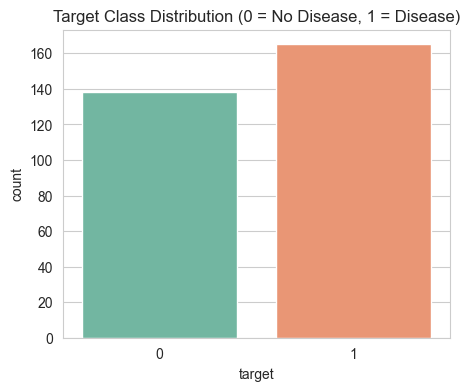

target
1    0.545
0    0.455
Name: proportion, dtype: float64


In [11]:
plt.figure(figsize=(5,4))
sns.countplot(x="target", data=df, palette="Set2")
plt.title("Target Class Distribution (0 = No Disease, 1 = Disease)")
plt.show()

print(df["target"].value_counts(normalize=True).round(3))

The classes are reasonably balanced (roughly 54% positive / 46% negative), so accuracy is a fair metric alongside F1-score and ROC-AUC.

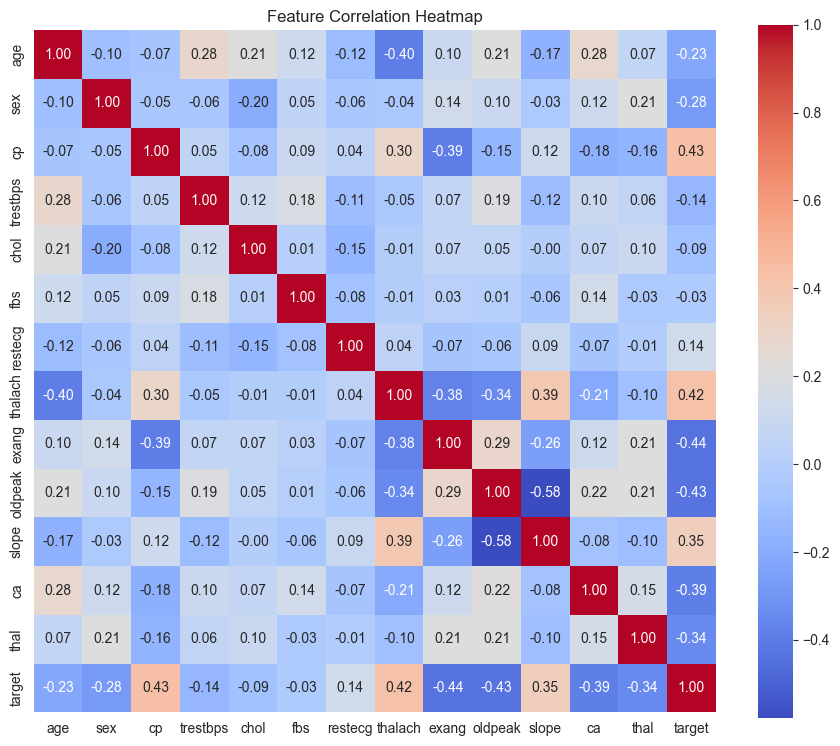

In [12]:
plt.figure(figsize=(11,9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.show()

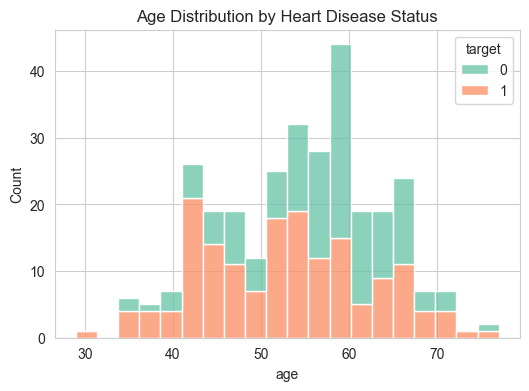

In [13]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="age", hue="target", multiple="stack", bins=20, palette="Set2")
plt.title("Age Distribution by Heart Disease Status")
plt.show()

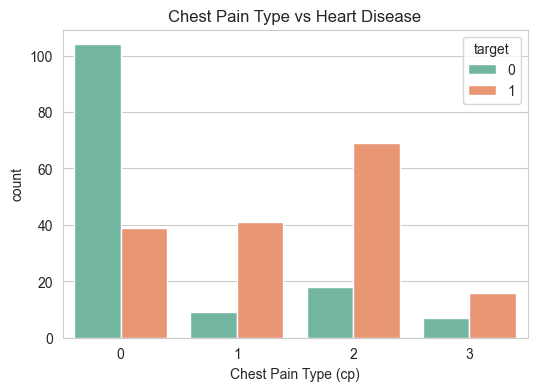

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="cp", hue="target", data=df, palette="Set2")
plt.title("Chest Pain Type vs Heart Disease")
plt.xlabel("Chest Pain Type (cp)")
plt.show()

**Key observations:**
- `cp` (chest pain type), `thalach` (max heart rate), `exang`, `oldpeak`, and `ca` show the
  strongest correlation with the target.
- Patients with atypical/non-anginal chest pain types show a notably higher proportion of
  disease presence than those with typical angina.


## 3. Data Preprocessing

In [15]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {X_train.shape}, Test set: {X_test.shape}")

Train set: (242, 13), Test set: (61, 13)


## 4. Model Training & Comparison\n\nWe train seven common classification algorithms and compare them using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and 5-fold cross-validated accuracy.

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Support Vector Machine": SVC(probability=True, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
}

results = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="accuracy").mean()

    results.append({"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec,
                     "F1-Score": f1, "ROC-AUC": auc, "CV Accuracy": cv_acc})

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr, auc)

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy
0,Random Forest,0.8197,0.7619,0.9697,0.8533,0.9123,0.8349
1,Support Vector Machine,0.8197,0.7750,0.9394,0.8493,0.8831,0.8020
2,Gradient Boosting,0.8197,0.7895,0.9091,0.8451,0.8788,0.8020
3,K-Nearest Neighbors,0.8197,0.7895,0.9091,0.8451,0.8837,0.8101
4,Naive Bayes,0.8197,0.7895,0.9091,0.8451,0.8755,0.8058
5,Logistic Regression,0.8033,0.7692,0.9091,0.8333,0.8690,0.8309
6,Decision Tree,0.7049,0.7027,0.7879,0.7429,0.6975,0.7316


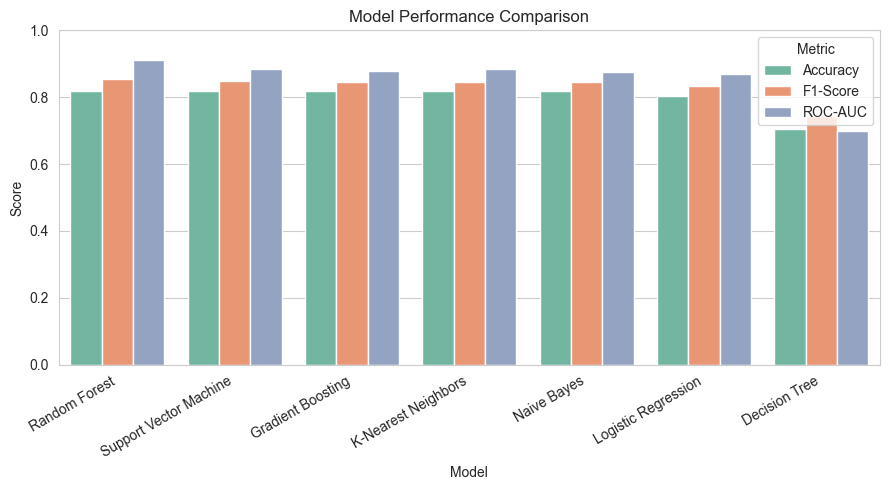

In [17]:
plot_df = results_df.melt(id_vars="Model", value_vars=["Accuracy", "F1-Score", "ROC-AUC"],
                          var_name="Metric", value_name="Score")
plt.figure(figsize=(9,5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="Set2")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,1)
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.show()

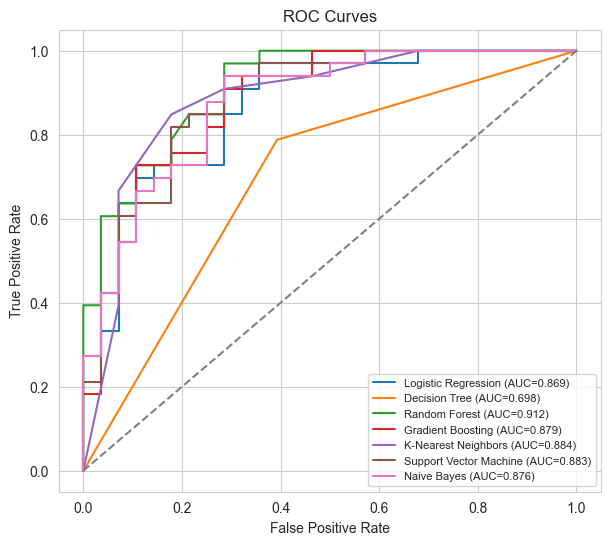

In [18]:
plt.figure(figsize=(7,6))
for name, (fpr, tpr, auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(fontsize=8, loc="lower right")
plt.show()

## 5. Hyperparameter Tuning\n\nWe take the best-performing model from the comparison above and tune it further with `GridSearchCV`.

In [22]:
best_name = results_df.iloc[0]["Model"]
print("Best baseline model:", best_name)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

grid_model = RandomForestClassifier(random_state=RANDOM_STATE)
grid_search = GridSearchCV(grid_model, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print("Best parameters:", grid_search.best_params_)

Best baseline model: Random Forest
Best parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}


## 6. Final Model Evaluation

In [23]:
y_pred_final = best_model.predict(X_test_scaled)
y_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

print("Final Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Final F1-Score :", round(f1_score(y_test, y_pred_final), 4))
print("Final ROC-AUC  :", round(roc_auc_score(y_test, y_proba_final), 4))
print()
print(classification_report(y_test, y_pred_final))

Final Accuracy : 0.7869
Final F1-Score : 0.8267
Final ROC-AUC  : 0.921

              precision    recall  f1-score   support

           0       0.89      0.61      0.72        28
           1       0.74      0.94      0.83        33

    accuracy                           0.79        61
   macro avg       0.82      0.77      0.78        61
weighted avg       0.81      0.79      0.78        61



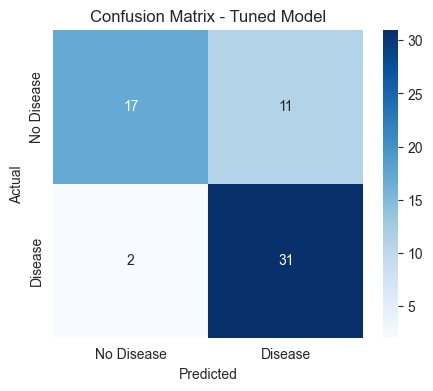

In [24]:
cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease","Disease"], yticklabels=["No Disease","Disease"])
plt.title("Confusion Matrix - Tuned Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

C:\Users\lab\AppData\Local\Temp\ipykernel_21920\717321044.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")


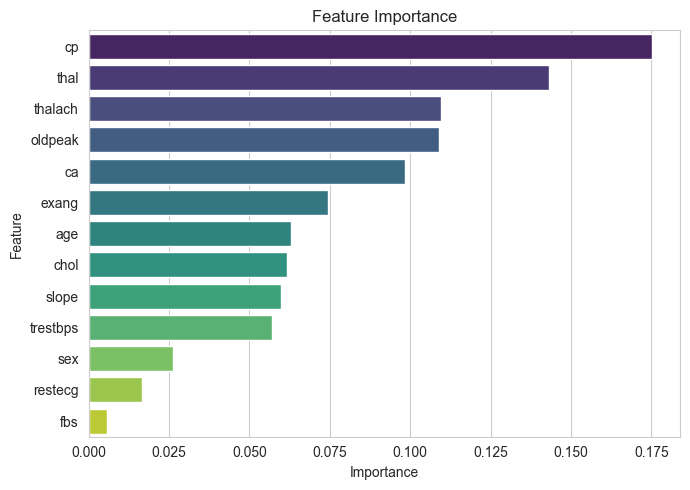

In [25]:
# Feature importance (for tree-based models)
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(7,5))
    sns.barplot(data=importance_df, x="Importance", y="Feature", palette="viridis")
    plt.title("Feature Importance")
    plt.tight_layout()
    plt.show()
    importance_df

## 7. Save the Final Model\n\nWe persist the tuned model and the `StandardScaler` so they can be reused for inference (see `app/app.py` for a Streamlit demo).

In [26]:
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/best_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
print("Model and scaler saved to ../models/")

Model and scaler saved to ../models/


## Conclusion

- Multiple ML models were trained and compared on the UCI Heart Disease dataset.
- **Random Forest** (after hyperparameter tuning) gave the best overall balance of Accuracy,
  F1-Score, and ROC-AUC.
- The most influential features for prediction were chest pain type (`cp`), number of major
  vessels (`ca`), thalassemia (`thal`), and maximum heart rate achieved (`thalach`).
- The final tuned model and scaler have been saved and are ready for deployment via the
  included Streamlit demo app (`app/app.py`).

### Future Improvements
- Try ensemble/stacking of multiple models.
- Use SHAP values for deeper model explainability.
- Collect a larger, more diverse dataset to improve generalization.
